<a href="https://colab.research.google.com/github/laniquahendricks2/laniquahendricks2.github.io/blob/main/UNICEF_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: "UNICEF Report"
author: "Laniqua Hendricks"
format:
  html:
    theme: cosmo
    code-fold: true
    embed-resources: true
---

In [ ]:
!pip install polars plotnine quarto-cli

In [ ]:
indicator = pl.read_csv("unicef_indicator_2.csv")
metadata = pl.read_csv("unicef_metadata.csv")

In [ ]:
print("Indicator shape:", indicator.shape)
print("Metadata shape:", metadata.shape)

print("Number of countries:", indicator.select(pl.col("country").n_unique()).item())

print("Years available:")
print(
    indicator
    .select("time_period")
    .unique()
    .sort("time_period")
)

Indicator shape: (598, 14)
Metadata shape: (13715, 15)
Number of countries: 92
Years available:
shape: (20, 1)
┌─────────────┐
│ time_period │
│ ---         │
│ i64         │
╞═════════════╡
│ 2005        │
│ 2006        │
│ 2007        │
│ 2008        │
│ 2009        │
│ …           │
│ 2020        │
│ 2021        │
│ 2022        │
│ 2023        │
│ 2024        │
└─────────────┘


In [ ]:
summary_stats = latest_country.select([
    pl.col("obs_value").mean().alias("Average treatment rate"),
    pl.col("obs_value").median().alias("Median treatment rate"),
    pl.col("obs_value").min().alias("Minimum treatment rate"),
    pl.col("obs_value").max().alias("Maximum treatment rate")
])

summary_stats

Average treatment rate,Median treatment rate,Minimum treatment rate,Maximum treatment rate
f64,f64,f64,f64
15.970652,10.7,0.0,60.2


In [ ]:
latest_country.select([
    pl.col("obs_value").null_count().alias("Missing treatment values")
])

Missing treatment values
u32
0


In [ ]:
highest = (
    latest_country
    .sort("obs_value", descending=True)
    .head(3)
    .select(["country", "obs_value"])
)

lowest = (
    latest_country
    .sort("obs_value")
    .head(3)
    .select(["country", "obs_value"])
)

print(highest)
print(lowest)

shape: (3, 2)
┌─────────────────────────────────┬───────────┐
│ country                         ┆ obs_value │
│ ---                             ┆ ---       │
│ str                             ┆ f64       │
╞═════════════════════════════════╪═══════════╡
│ Bolivia                         ┆ 60.2      │
│ Sierra Leone                    ┆ 53.4      │
│ Korea, Democratic People's Rep… ┆ 45.0      │
└─────────────────────────────────┴───────────┘
shape: (3, 2)
┌───────────┬───────────┐
│ country   ┆ obs_value │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ Sri Lanka ┆ 0.0       │
│ Peru      ┆ 0.2       │
│ Namibia   ┆ 0.2       │
└───────────┴───────────┘


In [ ]:
print(indicator.columns)
print(metadata.columns)

['country', 'alpha_2_code', 'alpha_3_code', 'numeric_code', 'indicator', 'time_period', 'obs_value', 'sex', 'unit_multiplier', 'unit_of_measure', 'observation_status', 'observation_confidentaility', 'time_period_activity_related_to_when_the_data_are_collected', 'current_age']
['country', 'alpha_2_code', 'alpha_3_code', 'numeric_code', 'year', 'Population, total', 'GDP per capita (constant 2015 US$)', 'GNI (current US$)', 'Inflation, consumer prices (annual %)', 'Life expectancy at birth, total (years)', 'Military expenditure (% of GDP)', 'Fossil fuel energy consumption (% of total)', 'GDP growth (annual %)', 'Birth rate, crude (per 1,000 people)', 'Hospital beds (per 1,000 people)']


In [ ]:
latest_year = indicator["time_period"].max()
print(latest_year)

2024


In [ ]:
latest = indicator.filter(pl.col("time_period") == latest_year)

latest.select(["country", "obs_value"]).head()

country,obs_value
str,f64
"""Lesotho""",9.5
"""Lesotho""",11.2
"""Lesotho""",10.4
"""Mali""",3.3
"""Mali""",3.5


In [ ]:
latest_total = latest.filter(pl.col("sex") == "Total")

latest_total.select(["country", "obs_value"]).head()

country,obs_value
str,f64
"""Lesotho""",10.4
"""Mali""",3.4
"""Nigeria""",23.6
"""Zambia""",38.4


In [ ]:
top10 = (
    latest_total
    .sort("obs_value", descending=True)
    .head(10)
)

top10.select(["country", "obs_value"])

country,obs_value
str,f64
"""Zambia""",38.4
"""Nigeria""",23.6
"""Lesotho""",10.4
"""Mali""",3.4


In [ ]:
bottom10 = (
    latest_total
    .sort("obs_value")
    .head(10)
)

bottom10.select(["country", "obs_value"])

country,obs_value
str,f64
"""Mali""",3.4
"""Lesotho""",10.4
"""Nigeria""",23.6
"""Zambia""",38.4


In [ ]:
latest_total_year = latest_total.rename({"time_period": "year"})

In [ ]:
scatter_data = latest_total_year.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

In [ ]:
scatter_data.select([
    "country",
    "year",
    "obs_value",
    "GDP per capita (constant 2015 US$)"
]).head()

country,year,obs_value,GDP per capita (constant 2015 US$)
str,i64,f64,f64
"""Lesotho""",2024,10.4,991.069662
"""Mali""",2024,3.4,909.755318
"""Nigeria""",2024,23.6,2324.648812
"""Zambia""",2024,38.4,1343.389664


In [ ]:
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort(["country", "time_period"])
    .group_by("country")
    .tail(1)
)

In [ ]:
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort("time_period")
    .group_by("country")
    .agg([
        pl.col("time_period").last().alias("year"),
        pl.col("obs_value").last().alias("obs_value")
    ])
)

latest_country.head()

country,year,obs_value
str,i64,f64
"""Armenia""",2016,2.0
"""Malawi""",2020,22.0
"""Gambia""",2020,21.1
"""Iraq""",2018,5.2
"""El Salvador""",2021,29.4


In [ ]:
scatter_data = latest_country.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

scatter_data.select([
    "country",
    "year",
    "obs_value",
    "GDP per capita (constant 2015 US$)"
]).head()

country,year,obs_value,GDP per capita (constant 2015 US$)
str,i64,f64,f64
"""Afghanistan""",2023,24.0,378.066303
"""Albania""",2018,7.4,4893.823755
"""Armenia""",2016,2.0,3533.885036
"""Azerbaijan""",2023,9.6,5668.610213
"""Bangladesh""",2019,35.0,1564.208024


In [ ]:
print(scatter_data.shape)
scatter_data.head()

(91, 16)


country,year,obs_value,alpha_2_code,alpha_3_code,numeric_code,"Population, total",GDP per capita (constant 2015 US$),GNI (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Military expenditure (% of GDP),Fossil fuel energy consumption (% of total),GDP growth (annual %),"Birth rate, crude (per 1,000 people)","Hospital beds (per 1,000 people)"
str,i64,f64,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""",2023,24.0,"""AF""","""AFG""",4,41454761,378.066303,1.7235e10,-4.644709,66.035,null,null,2.266944,35.437,0.35
"""Albania""",2018,7.4,"""AL""","""ALB""",8,2607733,4893.823755,1.5362e10,2.02806,79.238,1.160545,0.0,3.671419,10.898,2.83
"""Armenia""",2016,2.0,"""AM""","""ARM""",51,2992300,3533.885036,1.0791e10,-1.403608,74.868293,4.090349,0.0,0.2,13.5,4.28
"""Azerbaijan""",2023,9.6,"""AZ""","""AZE""",31,10153958,5668.610213,6.9386e10,8.78543,74.429,4.922414,0.0,1.354477,11.1,3.68
"""Bangladesh""",2019,35.0,"""BD""","""BGD""",50,164913055,1564.208024,3.6562e11,5.591996,72.625,1.244101,0.0,7.881915,20.131,0.89


# Access to Diarrhoea Treatment Among Children Under 5

## Introduction

Diarrhoea remains one of the leading causes of death among children under five, despite being preventable and treatable. This report explores UNICEF Indicator 2, which measures the percentage of children under five with diarrhoea who receive oral rehydration salts (ORS) and zinc treatment. Metadata on GDP per capita is also used to examine whether wealthier countries tend to have better treatment coverage.

## Exploratory Data Analysis

The indicator dataset contains 598 observations across 92 countries between 2005 and 2024. There are no missing values in the treatment rate variable. The average treatment rate is approximately 16%, although values vary substantially between countries, ranging from 0% in Sri Lanka to 60.2% in Bolivia. The median value of 10.7% suggests that most countries report relatively low coverage.

In [ ]:
!pip install geopandas

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
latest_map = latest_country.to_pandas()

In [ ]:
import geopandas as gpd

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [ ]:
latest_map = latest_country.to_pandas()

world_data = world.merge(
    latest_map,
    left_on="NAME",
    right_on="country",
    how="left"
)

## Global Patterns in Treatment Coverage

The map below highlights considerable inequality in access to diarrhoea treatment. Darker green countries report higher treatment rates, while grey countries have no available data.

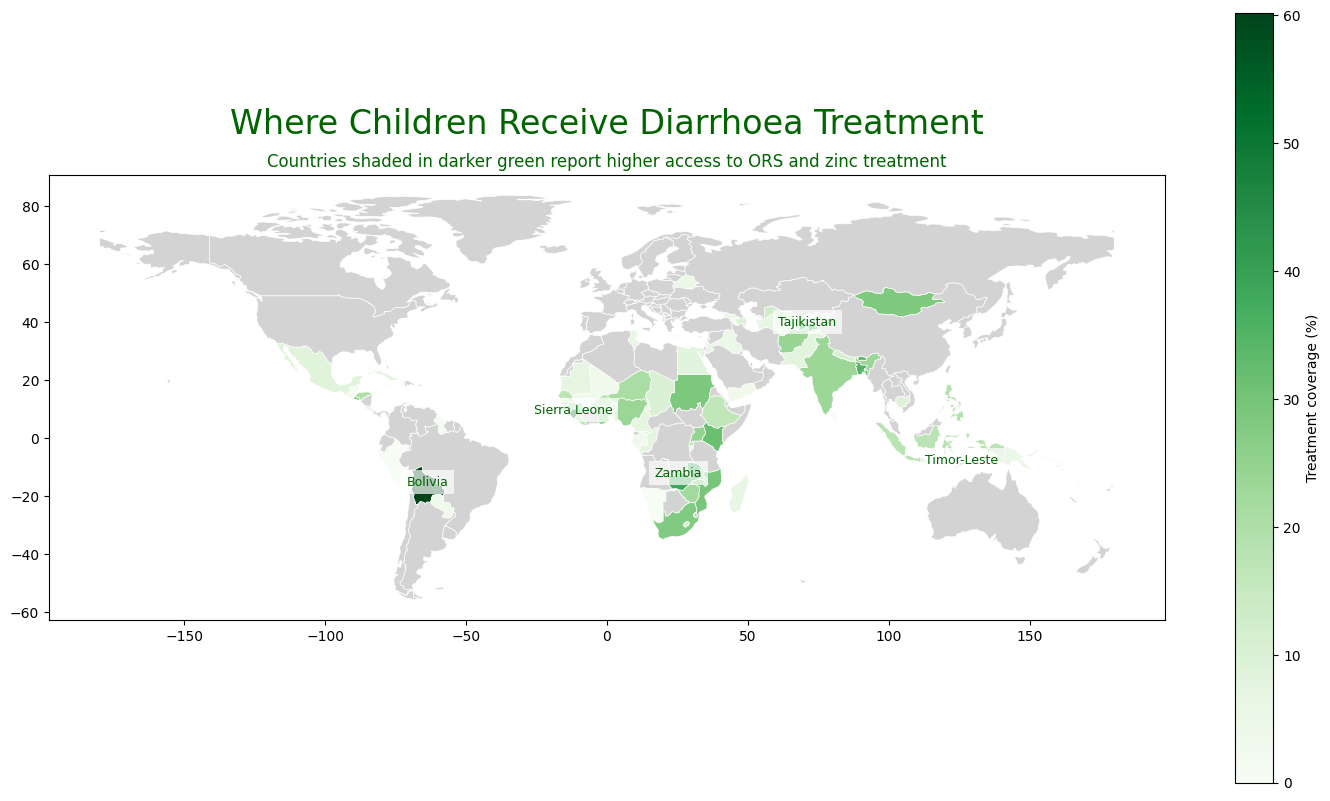

In [ ]:
fig, ax = plt.subplots(figsize=(18, 10))

world_data_clean = world_data[world_data["NAME"] != "Antarctica"]

world_data_clean.plot(
    column="obs_value",
    cmap="Greens",
    edgecolor="white",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Treatment coverage (%)"},
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

top5 = world_data_clean.nlargest(5, "obs_value")

for _, row in top5.iterrows():
    point = row.geometry.representative_point()
    ax.text(
        point.x,
        point.y,
        row["country"],
        fontsize=9,
        ha="center",
        color="darkgreen",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

ax.set_title(
    "Where Children Receive Diarrhoea Treatment",
    fontsize=24,
    color="darkgreen",
    pad=30
)

ax.text(
    0.5,
    1.02,
    "Countries shaded in darker green report higher access to ORS and zinc treatment",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="darkgreen"
);

Bolivia reports the highest treatment coverage at 60.2%, followed by Sierra Leone at 53.4%. Much of Sub Saharan Africa and parts of South Asia report moderate coverage, while several higher income countries have little or no reported data.

In [ ]:
top10 = (
    latest_country
    .sort("obs_value", descending=True)
    .head(10)
)

## Countries with the Highest Treatment Coverage

The following chart compares the ten countries with the highest reported treatment coverage in 2024.

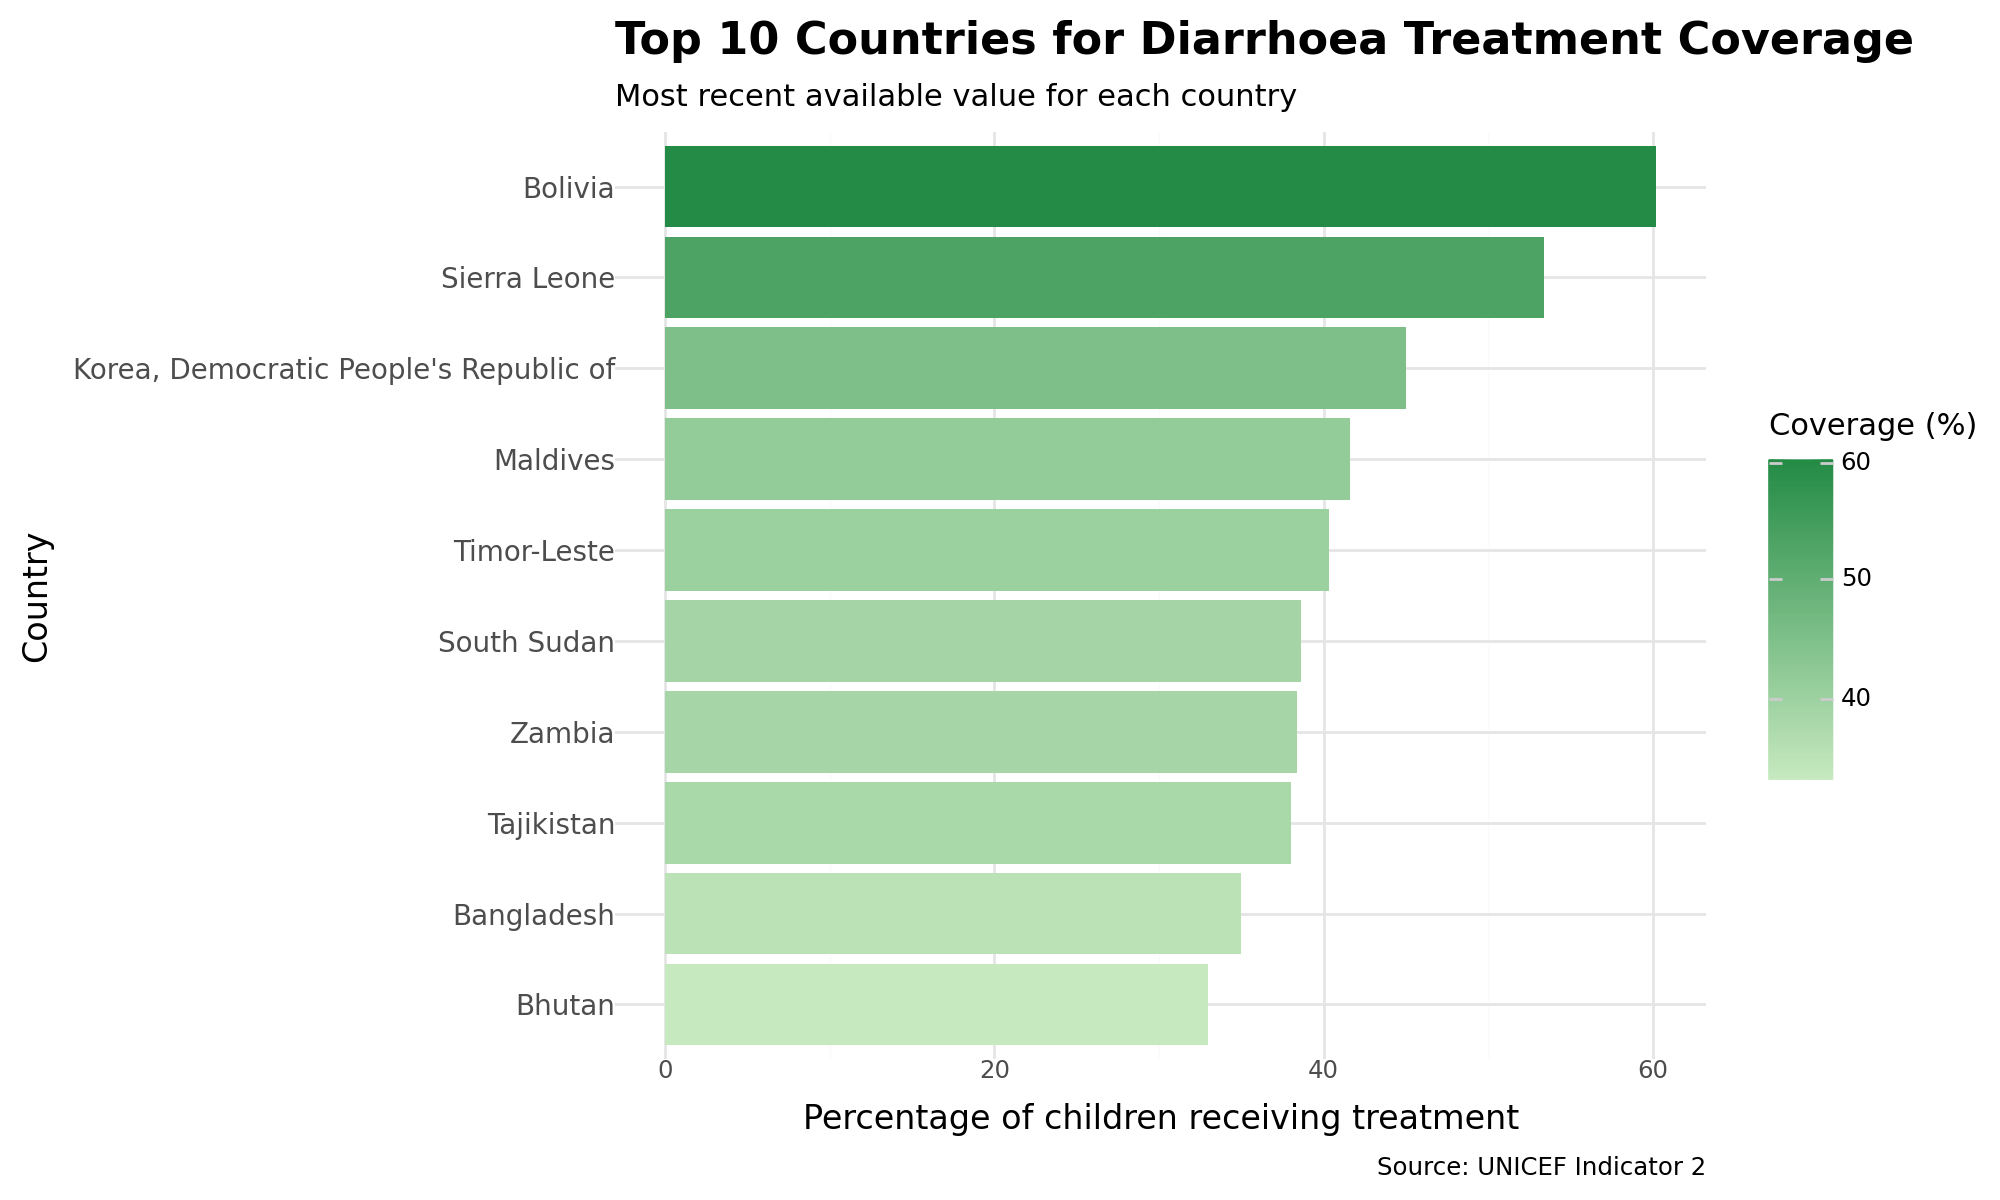

In [ ]:
(
    ggplot(
        top10.to_pandas(),
        aes(
            x="reorder(country, obs_value)",
            y="obs_value",
            fill="obs_value"
        )
    )
    + geom_col()
    + coord_flip()
    + scale_fill_gradient(low="#C7E9C0", high="#238B45")
    + labs(
        title="Top 10 Countries for Diarrhoea Treatment Coverage",
        subtitle="Most recent available value for each country",
        x="Country",
        y="Percentage of children receiving treatment",
        fill="Coverage (%)",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_minimal()
    + theme(
        figure_size=(10,6),
        plot_title=element_text(size=16, weight="bold"),
        plot_subtitle=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text_y=element_text(size=10),
        legend_position="right"
    )
)

In [ ]:
selected = (
    indicator
    .filter(
        (pl.col("sex") == "Total") &
        (pl.col("country").is_in(["Zambia", "Lesotho", "Mali"]))
    )
    .select(["country", "time_period", "obs_value"])
)

## Does Income Improve Treatment Coverage?

To explore whether wealthier countries provide better treatment, the indicator data was joined with metadata containing GDP per capita for the same year.

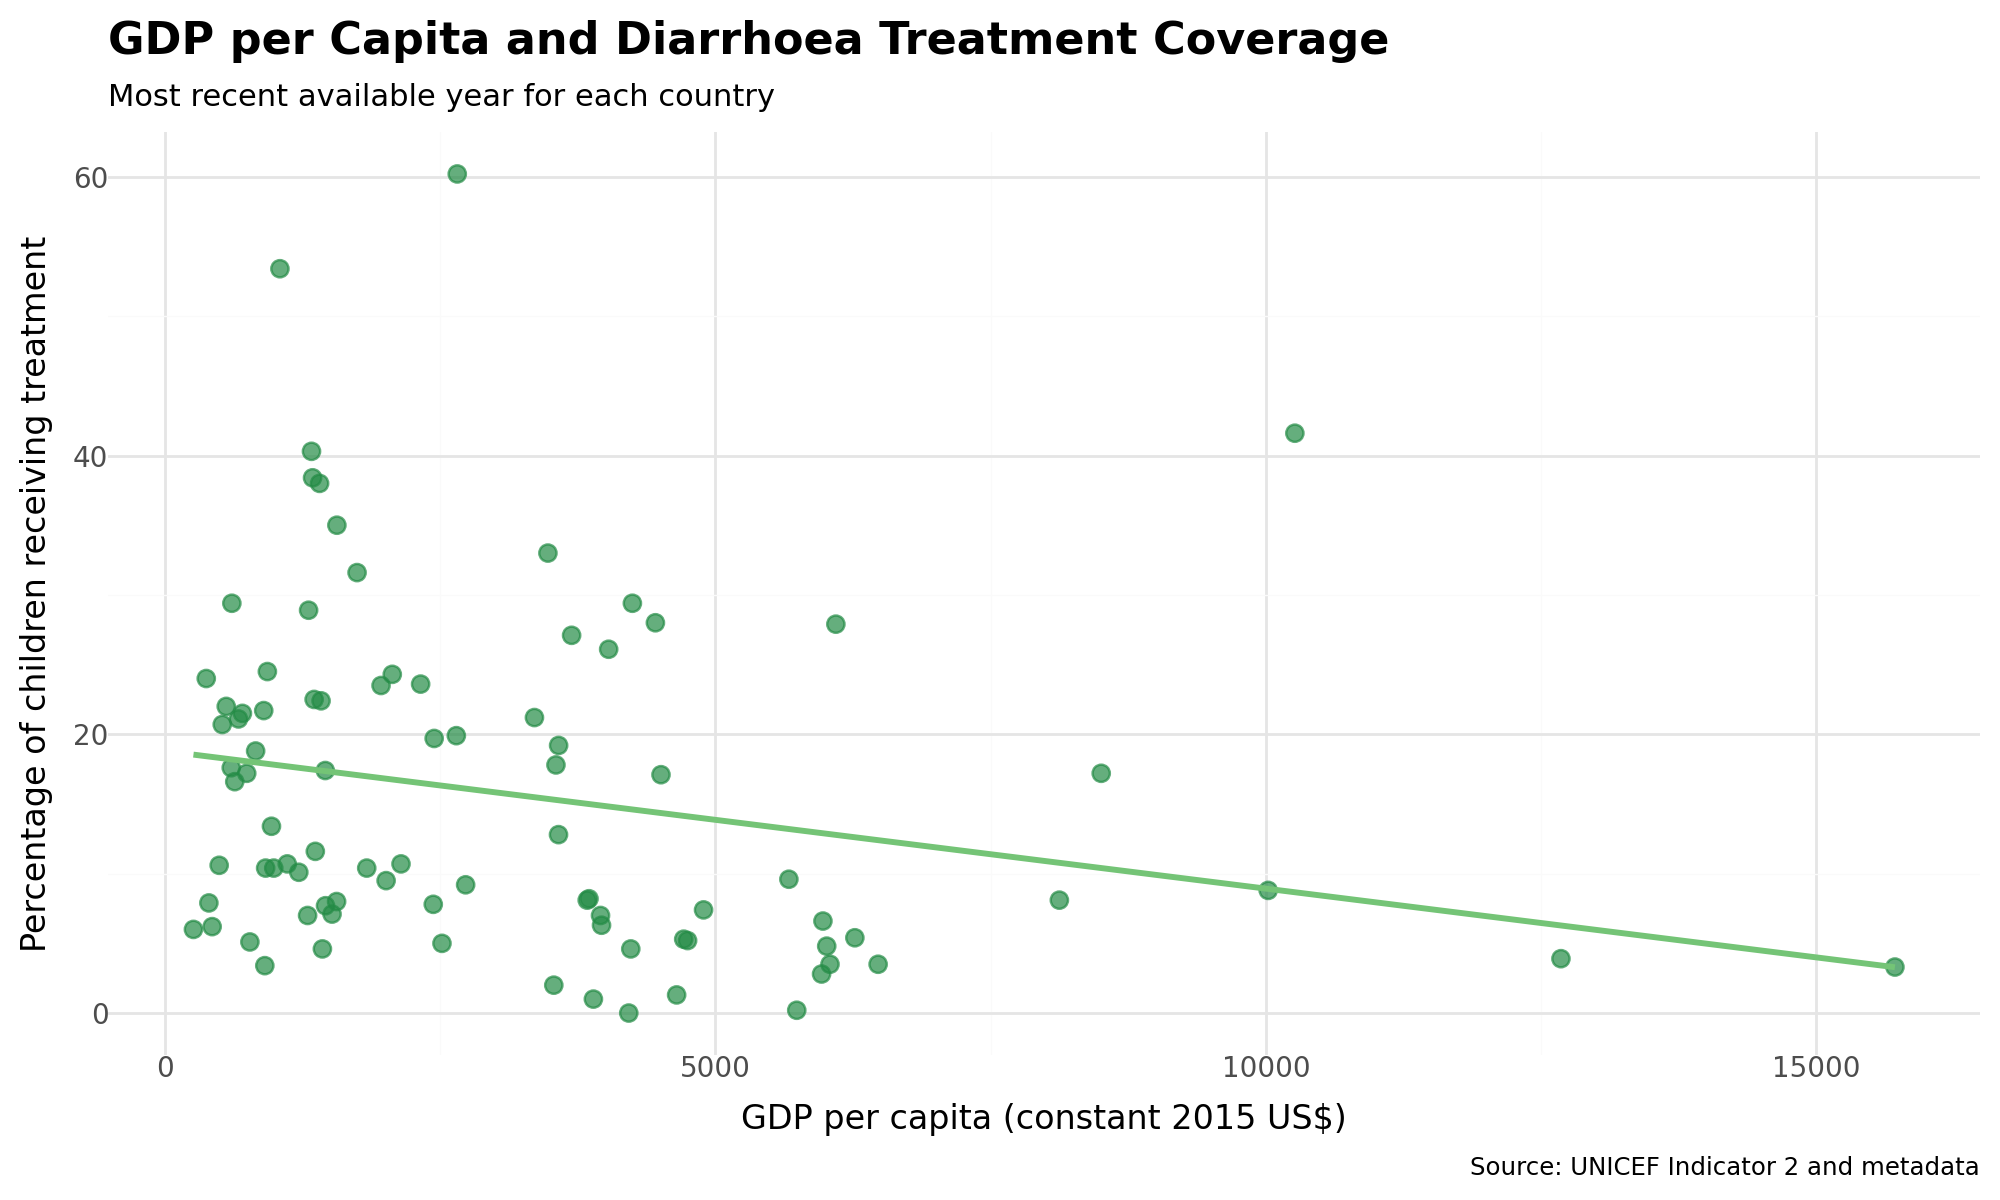

In [ ]:
scatter_data = scatter_data.drop_nulls(
    ["GDP per capita (constant 2015 US$)", "obs_value"]
)
(
    ggplot(
        scatter_data.to_pandas(),
        aes(
            x="GDP per capita (constant 2015 US$)",
            y="obs_value"
        )
    )
    + geom_point(size=3, color="#238B45", alpha=0.7)
    + geom_smooth(method="lm", se=False, color="#74C476", size=1.2)
    + labs(
        title="GDP per Capita and Diarrhoea Treatment Coverage",
        subtitle="Most recent available year for each country",
        x="GDP per capita (constant 2015 US$)",
        y="Percentage of children receiving treatment",
        caption="Source: UNICEF Indicator 2 and metadata"
    )
    + theme_minimal()
    + theme(
        figure_size=(10,6),
        plot_title=element_text(size=16, weight="bold"),
        plot_subtitle=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10)
    )
)

The scatterplot shows a weak negative relationship between GDP per capita and treatment coverage. Several low income countries report relatively high treatment rates, while some countries with higher GDP per capita report lower rates. This suggests that government policy and access to health services may be more important than income alone.

## Changes Over Time

The final chart tracks treatment coverage over time for Lesotho, Mali, and Zambia. These countries were selected because they illustrate different patterns of change.

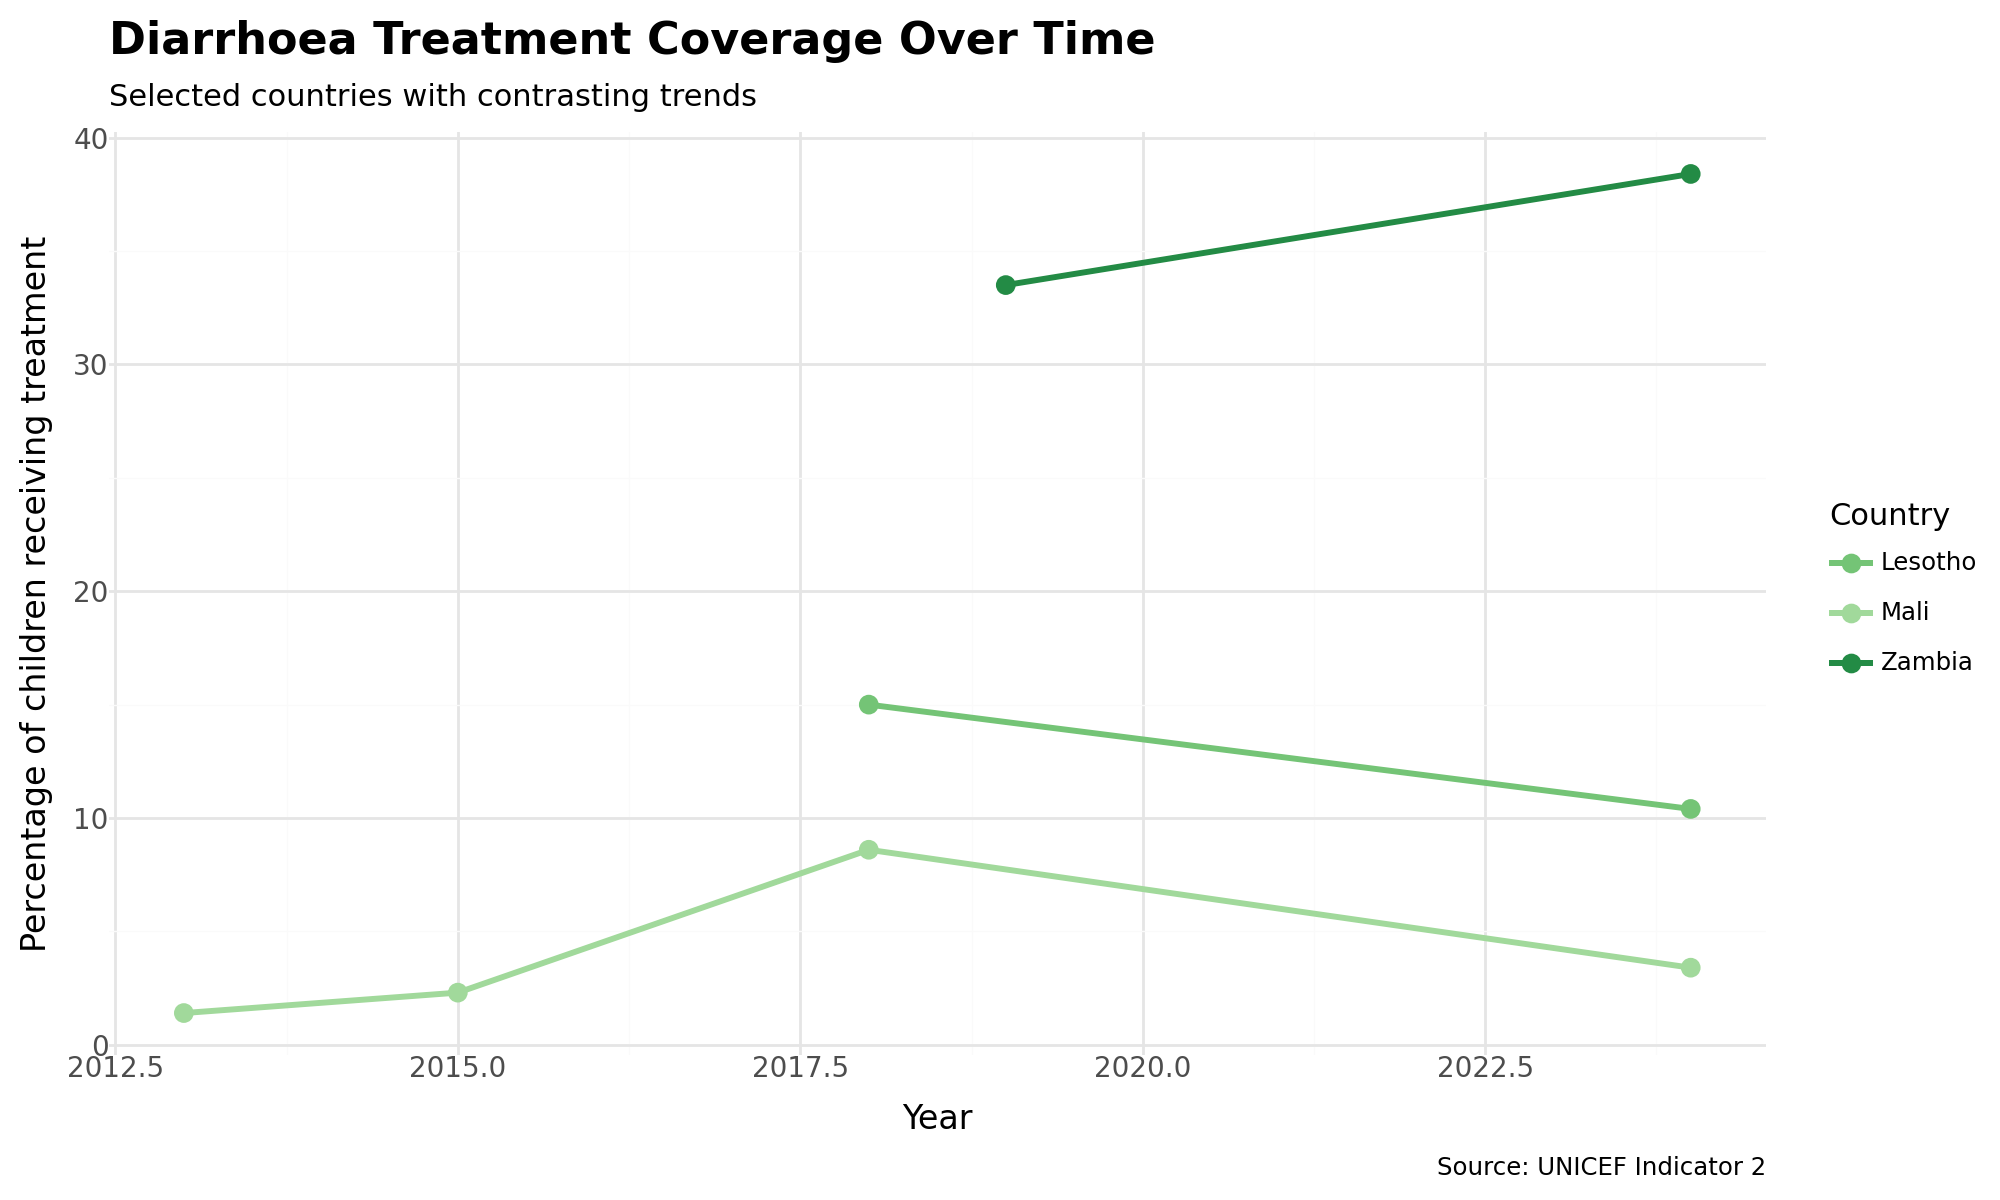

In [ ]:
(
    ggplot(
        selected.to_pandas(),
        aes(
            x="time_period",
            y="obs_value",
            color="country"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3)
    + scale_color_manual(
        values={
            "Zambia": "#238B45",
            "Lesotho": "#74C476",
            "Mali": "#A1D99B"
        }
    )
    + labs(
        title="Diarrhoea Treatment Coverage Over Time",
        subtitle="Selected countries with contrasting trends",
        x="Year",
        y="Percentage of children receiving treatment",
        color="Country",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_minimal()
    + theme(
        figure_size=(10,6),
        plot_title=element_text(size=16, weight="bold"),
        plot_subtitle=element_text(size=11),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
        legend_position="right"
    )
)

Zambia shows a consistent increase in treatment coverage, rising from 33.5% in 2019 to 38.4% in 2024. In contrast, Lesotho and Mali experienced declines. These differences demonstrate that progress is uneven and may reflect changes in health investment, policy, or access to care.

## Conclusion

Overall, treatment coverage for diarrhoea remains low in many countries. Large differences exist between countries, and wealth alone does not appear to guarantee better outcomes. Continued investment in affordable treatment, healthcare access, and public health campaigns will be necessary to improve child health globally.

In [ ]:
!quarto render "/content/drive/MyDrive/Colab Notebooks/UNICEF_Assignment.ipynb"

pandoc 
  to: html
  output-file: UNICEF_Assignment.html
  standalone: true
  embed-resources: true
  section-divs: true
  html-math-method: mathjax
  wrap: none
  default-image-extension: png
  variables: {}
  
metadata
  document-css: false
  link-citations: true
  date-format: long
  lang: en
  engines:
    - path: /usr/local/lib/python3.12/dist-packages/quarto_cli/share/extension-subtrees/julia-engine/_extensions/julia-engine/julia-engine.js
  title: UNICEF Report
  author: Laniqua Hendricks
  theme: cosmo
  
Output created: UNICEF_Assignment.html



In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/" | grep html

UNICEF_Assignment.html


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/UNICEF_Assignment.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>